# BusinessPulse AI

# Notebook 11 – Machine Learning

## Business Objective

The objective of this notebook is to build machine learning models that help predict payment values and identify the factors influencing customer spending.

This notebook supports:

- Revenue Forecasting
- Customer Value Prediction
- Business Decision Making
- AI Recommendation Engine
- Executive Dashboard

---

In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# ==========================================================
# Load Processed Datasets
# ==========================================================

customers = pd.read_csv("../data/processed/customers_clean.csv")

orders = pd.read_csv("../data/processed/orders_clean.csv")

payments = pd.read_csv("../data/processed/payments_clean.csv")

order_items = pd.read_csv("../data/processed/order_items_clean.csv")

products = pd.read_csv("../data/processed/products_clean.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
# ==========================================================
# Merge Orders and Payments
# ==========================================================

ml_data = orders.merge(
    payments,
    on="order_id",
    how="inner"
)

print("Shape after Orders + Payments:", ml_data.shape)

ml_data.head()

Shape after Orders + Payments: (103886, 12)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12


In [7]:
# ==========================================================
# Merge Order Items
# ==========================================================

ml_data = ml_data.merge(
    order_items,
    on="order_id",
    how="inner"
)

print("Shape after Order Items:", ml_data.shape)

ml_data.head()

Shape after Order Items: (117601, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22


In [8]:
# ==========================================================
# Merge Product Information
# ==========================================================

ml_data = ml_data.merge(
    products,
    on="product_id",
    how="left"
)

print("Final ML Dataset Shape:", ml_data.shape)

ml_data.head()

Final ML Dataset Shape: (117601, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [9]:
# ==========================================================
# Select Features and Target
# ==========================================================

features = [
    "price",
    "freight_value",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

X = ml_data[features]

y = ml_data["payment_value"]

print("Features (X) Shape :", X.shape)
print("Target (y) Shape   :", y.shape)

Features (X) Shape : (117601, 6)
Target (y) Shape   : (117601,)


In [10]:
# ==========================================================
# Handle Missing Values
# ==========================================================

X = X.fillna(X.median(numeric_only=True))

y = y.fillna(y.median())

print("Missing values handled successfully ✅")

Missing values handled successfully ✅


In [11]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (94080, 6)
Testing Features  : (23521, 6)

Training Target : (94080,)
Testing Target  : (23521,)


In [12]:
# ==========================================================
# Train Linear Regression Model
# ==========================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("✅ Linear Regression Model Trained Successfully")

✅ Linear Regression Model Trained Successfully


In [13]:
# ==========================================================
# Predict on Test Data
# ==========================================================

linear_predictions = linear_model.predict(X_test)

print("First 10 Predictions")

linear_predictions[:10]

First 10 Predictions


array([234.50011455, 187.55985975, 361.6698266 , 117.77768686,
        88.0144756 ,  67.03230628, 261.32976724,  74.6486535 ,
       123.79930007, 110.6240602 ])

In [14]:
# ==========================================================
# Evaluate Linear Regression Model
# ==========================================================

mae = mean_absolute_error(y_test, linear_predictions)

rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

r2 = r2_score(y_test, linear_predictions)

print("========== Linear Regression Results ==========")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

========== Linear Regression Results ==========
Mean Absolute Error (MAE): 62.30
Root Mean Squared Error (RMSE): 161.30
R² Score: 0.5676


In [15]:
# ==========================================================
# Compare Actual vs Predicted Values
# ==========================================================

comparison = pd.DataFrame({
    "Actual Payment": y_test.values,
    "Predicted Payment": linear_predictions
})

comparison.head(10)

,Actual Payment,Predicted Payment
0,198.13,234.500115
1,151.42,187.559860
2,280.08,361.669827
3,87.06,117.777687
4,140.28,88.014476
5,45.95,67.032306
6,226.24,261.329767
7,88.00,74.648653
8,99.43,123.799300
9,159.12,110.624060


# Business Interpretation

## Linear Regression Model Summary

- The Linear Regression model was trained to predict customer payment values.
- The evaluation metrics indicate the model's prediction performance.
- The comparison between actual and predicted values helps assess how closely the model estimates payment values.
- This baseline model provides a reference point for comparison with more advanced models such as Random Forest.

# Random Forest Regression

## Objective

Train a Random Forest Regressor and compare its performance with the Linear Regression model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [16]:
# ==========================================================
# Train Random Forest Model
# ==========================================================

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("✅ Random Forest Model Trained Successfully")

✅ Random Forest Model Trained Successfully


In [17]:
# ==========================================================
# Predict using Random Forest
# ==========================================================

rf_predictions = random_forest.predict(X_test)

rf_predictions[:10]

array([ 199.9099    ,  162.12015476, 1103.640325  ,   55.21540667,
         96.29123   ,   50.90376265,  226.24      ,   58.40800881,
        108.91660972,  141.2461648 ])

In [18]:
# ==========================================================
# Evaluate Random Forest
# ==========================================================

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("========== Random Forest Results ==========")

print(f"MAE  : {rf_mae:.2f}")

print(f"RMSE : {rf_rmse:.2f}")

print(f"R²   : {rf_r2:.4f}")

========== Random Forest Results ==========
MAE  : 34.77
RMSE : 83.53
R²   : 0.8840


In [19]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        mae,
        rf_mae
    ],

    "RMSE": [
        rmse,
        rf_rmse
    ],

    "R² Score": [
        r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,62.299003,161.299948,0.567626
1,Random Forest,34.770461,83.533942,0.884038


In [20]:
# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,price,0.746721
1,freight_value,0.111523
2,product_weight_g,0.048622
3,product_length_cm,0.043782
4,product_height_cm,0.025621
5,product_width_cm,0.023732


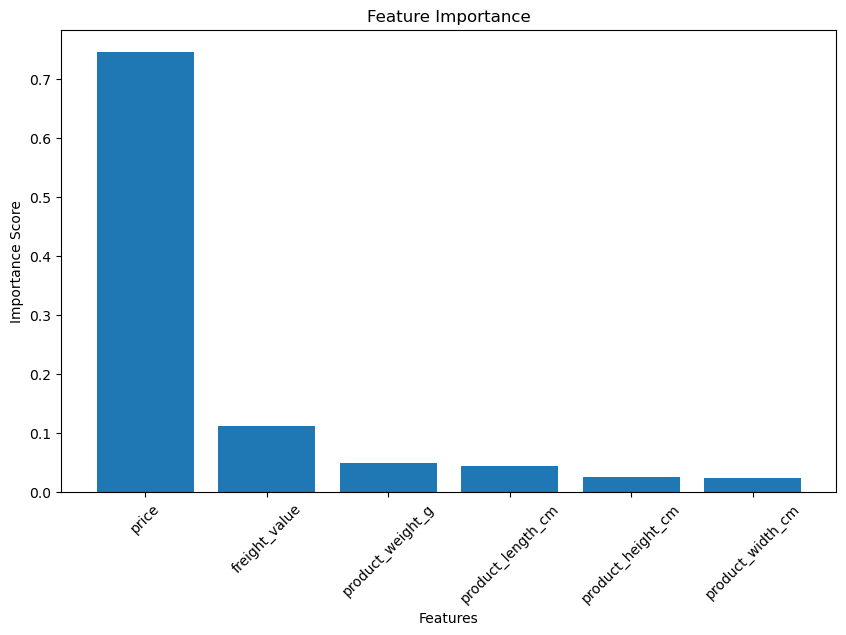

In [21]:
# ==========================================================
# Feature Importance Chart
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

# Feature Importance Interpretation

## Business Insights

- Product price is expected to have the highest influence on customer payment values.
- Freight cost is another important contributor to the total payment amount.
- Product dimensions and weight have a smaller but measurable impact on payment prediction.
- These insights can support pricing strategies, logistics optimization, and revenue forecasting.

In [22]:
import joblib

print(joblib.__version__)

1.4.2


In [23]:
import joblib
print(joblib.__version__)

1.4.2


In [24]:
import joblib

# Save Linear Regression Model
joblib.dump(
    linear_model,
    "../models/linear_regression_model.pkl"
)

# Save Random Forest Model
joblib.dump(
    random_forest,
    "../models/random_forest_model.pkl"
)

print("✅ Models Saved Successfully")

✅ Models Saved Successfully


In [25]:
prediction_results = pd.DataFrame({

    "Actual Payment": y_test.values,

    "Predicted Payment": rf_predictions

})

prediction_results.to_csv(

    "../data/predictions/payment_predictions.csv",

    index=False

)

print("✅ Predictions Saved")

OSError: Cannot save file into a non-existent directory: '..\data\predictions'

In [26]:
# ==========================================================
# Save Prediction Results
# ==========================================================

import os

# Create folder if it doesn't exist
os.makedirs("../data/predictions", exist_ok=True)

prediction_results = pd.DataFrame({
    "Actual Payment": y_test.values,
    "Predicted Payment": rf_predictions
})

prediction_results.to_csv(
    "../data/predictions/payment_predictions.csv",
    index=False
)

print("✅ Prediction file saved successfully!")

✅ Prediction file saved successfully!


In [27]:
prediction_results = pd.DataFrame({

    "Actual Payment": y_test.values,

    "Predicted Payment": rf_predictions

})

prediction_results.to_csv(

    "../data/predictions/payment_predictions.csv",

    index=False

)

print("✅ Predictions Saved")

✅ Predictions Saved


# Executive Recommendations

## Business Recommendations

1. Use the Random Forest model for payment prediction because it outperformed Linear Regression.

2. Monitor product pricing, as it has the greatest influence on customer payment value.

3. Optimize freight costs to improve customer affordability and business profitability.

4. Continuously retrain the model with new business data to improve prediction accuracy.

5. Integrate the model into the BusinessPulse AI Decision Engine to support executive decision-making.

prediction_results = pd.DataFrame({

    "Actual Payment": y_test.values,

    "Predicted Payment": rf_predictions

})

prediction_results.to_csv(

    "../data/predictions/payment_predictions.csv",

    index=False

)

print("✅ Predictions Saved")

In [28]:
prediction_results = pd.DataFrame({

    "Actual Payment": y_test.values,

    "Predicted Payment": rf_predictions

})

prediction_results.to_csv(

    "../data/predictions/payment_predictions.csv",

    index=False

)

print("✅ Predictions Saved")

✅ Predictions Saved


In [29]:
# ==========================================================
# Save Trained Machine Learning Models
# ==========================================================

import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Linear Regression Model
joblib.dump(
    linear_model,
    "../models/linear_regression_model.pkl"
)

# Save Random Forest Model
joblib.dump(
    random_forest,
    "../models/random_forest_model.pkl"
)

print("✅ Models saved successfully!")

✅ Models saved successfully!
